# Quantum circuits: gates, statevectors, measurement

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Broum/UKP_IQC_materials/blob/main/Qiskit_circuits_colab.ipynb)

Math recap &rarr; gates as matrices &rarr; building a circuit gate by gate &rarr; measurement.
Run the cells in order (`Shift+Enter`). Every code cell is meant to be edited and re-run.

## 0. Setup

Same as in `Qiskit_intro_colab.ipynb`: in Colab the packages are installed per session, so re-run
this cell after every runtime restart. For a local conda environment see that notebook.

In [180]:
%pip install -q qiskit qiskit-aer pylatexenc matplotlib

Note: you may need to restart the kernel to use updated packages.


In [181]:
import numpy as np
import qiskit
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.circuit.tools import pi_check
from qiskit.circuit.library import IGate, XGate, YGate, ZGate, HGate, SGate, TGate, RXGate, RYGate, RZGate, CXGate, CZGate, SwapGate
from qiskit.quantum_info import Statevector, DensityMatrix, Operator, Pauli, partial_trace, state_fidelity
from qiskit.visualization import array_to_latex, plot_bloch_multivector, plot_state_city, plot_histogram
from qiskit_aer import AerSimulator
from IPython.display import display

np.set_printoptions(precision=3, suppress=True)
print(qiskit.__version__)


def show(matrix, prefix=''):
    display(array_to_latex(np.asarray(matrix), prefix=prefix))


def braket(phi, psi):
    return (phi.conj().T @ psi).item()

2.1.2


## 1. Math recap

### 1.0 Math in NumPy

| math | NumPy | meaning |
|---|---|---|
| $\vert\psi\rangle$ | `np.array([[a], [b]])` | column vector, shape `(2, 1)` |
| $\langle\psi\vert = \vert\psi\rangle^\dagger$ | `psi.conj().T` | bra from ket: complex conjugate + transpose |
| $A^\dagger$ | `A.conj().T` | the same for a matrix |
| $AB$, $A\vert\psi\rangle$, $A^2$ | `A @ B`, `A @ psi`, `A @ A` | matrix product |
| $A\odot B$, $A^{\odot 2}$ | `A * B`, `A**2` | element-wise product, **not** the matrix product |
| $\langle\phi\vert\psi\rangle$ | `(phi.conj().T @ psi).item()` | `.item()`: $1\times 1$ matrix $\to$ number |
| $\vert\psi\rangle\langle\phi\vert$ | `psi @ phi.conj().T` or `np.outer(psi, phi.conj())` | outer product |
| $A\otimes B$ | `np.kron(A, B)` | tensor (Kronecker) product |
| $cA$ | `c * A` | number times matrix |
| $\mathrm{Tr}\,A$ | `np.trace(A)` | trace |
| $i$, $e^{i\varphi}$, $\vert c\vert^2$ | `1j`, `np.exp(1j*phi)`, `abs(c)**2` | |
| $A = B$ | `np.allclose(A, B)` | equal up to rounding errors |

**Careful:** `*` and `**` between two arrays work element by element; use `@` for the matrix product. (And `^` in Python is the bitwise XOR, not a power.)

In [182]:
A = np.array([[0, 1], [1, 0]])
B = np.array([[1, 0], [0, -1]])
show(A, r'A = ')
show(B, r'B = ')

show(A @ B, r'AB = ')
show(A * B, r'A \odot B = ')
show(A @ A, r'A^2 = ')
show(A**2, r'A^{\odot 2} = ')

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

### 1.1 Dirac notation

A ket is a column vector, a bra is its conjugate transpose:

$$|0\rangle = \begin{pmatrix}1\\0\end{pmatrix},\quad
|1\rangle = \begin{pmatrix}0\\1\end{pmatrix},\quad
|\psi\rangle = \alpha|0\rangle + \beta|1\rangle = \begin{pmatrix}\alpha\\\beta\end{pmatrix},\quad
\langle\psi| = |\psi\rangle^\dagger = (\alpha^*,\ \beta^*)$$

In [183]:
ket0 = np.array([[1], [0]], dtype=complex)
ket1 = np.array([[0], [1]], dtype=complex)

alpha, beta = 1/np.sqrt(3), 1j*np.sqrt(2/3)
psi = alpha*ket0 + beta*ket1

show(psi, r'|\psi\rangle = ')
show(psi.conj().T, r'\langle\psi| = ')

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

### 1.2 Inner (dot) product

$\langle\phi|\psi\rangle = \sum_i \phi_i^*\psi_i$. Normalisation: $\langle\psi|\psi\rangle = 1$, orthogonality: $\langle 0|1\rangle = 0$.
$|\langle\phi|\psi\rangle|^2$ is the probability of finding $|\psi\rangle$ in the state $|\phi\rangle$.

In [184]:
print('<psi|psi>   =', braket(psi, psi))
print('<0|1>       =', braket(ket0, ket1))
print(f'|<0|psi>|^2 = {abs(braket(ket0, psi))**2:.3f}')
print(f'|<1|psi>|^2 = {abs(braket(ket1, psi))**2:.3f}')

<psi|psi>   = (1+0j)
<0|1>       = 0j
|<0|psi>|^2 = 0.333
|<1|psi>|^2 = 0.667


### 1.3 Bases

Any two orthonormal vectors form a basis of one qubit. The coefficients of $|\psi\rangle$ in a basis $\{|b_0\rangle, |b_1\rangle\}$ are $c_i = \langle b_i|\psi\rangle$.

$$
\begin{aligned}
&\text{Z (computational):} && |0\rangle,\quad |1\rangle \\
&\text{X (Hadamard):} && |\pm\rangle = \tfrac{1}{\sqrt2}\left(|0\rangle \pm |1\rangle\right) \\
&\text{Y (circular):} && |\pm i\rangle = \tfrac{1}{\sqrt2}\left(|0\rangle \pm i|1\rangle\right)
\end{aligned}
$$

In [185]:
plus    = (ket0 + ket1) / np.sqrt(2)
minus   = (ket0 - ket1) / np.sqrt(2)
plus_i  = (ket0 + 1j*ket1) / np.sqrt(2)
minus_i = (ket0 - 1j*ket1) / np.sqrt(2)

bases = {'Z': (ket0, ket1), 'X': (plus, minus), 'Y': (plus_i, minus_i)}
for name, (b0, b1) in bases.items():
    c0, c1 = braket(b0, psi), braket(b1, psi)
    print(f'{name}: c0 = {c0:.3f}, c1 = {c1:.3f}, |c0|^2 + |c1|^2 = {abs(c0)**2 + abs(c1)**2:.3f}')

Z: c0 = 0.577+0.000j, c1 = 0.000+0.816j, |c0|^2 + |c1|^2 = 1.000
X: c0 = 0.408+0.577j, c1 = 0.408-0.577j, |c0|^2 + |c1|^2 = 1.000
Y: c0 = 0.986+0.000j, c1 = -0.169+0.000j, |c0|^2 + |c1|^2 = 1.000


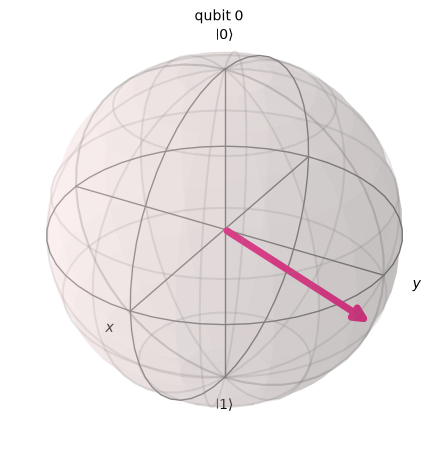

In [186]:
plot_bloch_multivector(Statevector(psi.ravel()))

### 1.4 Outer product, projectors

$|\psi\rangle\langle\phi|$ is a matrix. $P = |b\rangle\langle b|$ is a projector ($P^2 = P$),
and for any basis $\sum_i |b_i\rangle\langle b_i| = I$ (completeness).

In [187]:
P0, P1 = ket0 @ ket0.conj().T, ket1 @ ket1.conj().T
Pplus, Pminus = plus @ plus.conj().T, minus @ minus.conj().T

show(Pplus, r'|+\rangle\langle+| = ')
print('P^2 == P             :', np.allclose(Pplus @ Pplus, Pplus))
print('|0><0| + |1><1| == I :', np.allclose(P0 + P1, np.eye(2)))
print('|+><+| + |-><-| == I :', np.allclose(Pplus + Pminus, np.eye(2)))

<IPython.core.display.Latex object>

P^2 == P             : True
|0><0| + |1><1| == I : True
|+><+| + |-><-| == I : True


### 1.5 Tensor product, quantum registers

$n$ qubits are described by $2^n$ amplitudes: $|a\rangle\otimes|b\rangle = |ab\rangle$ (`np.kron`).
For matrices: $(A\otimes B)(|a\rangle\otimes|b\rangle) = A|a\rangle\otimes B|b\rangle$.

**Qiskit ordering (little-endian):** qubit 0 is the *rightmost* one, $|q_{n-1}\dots q_1 q_0\rangle$.
`'01'` therefore means $q_1 = 0,\ q_0 = 1$, and `Pauli('XI')` is $X$ on $q_1$.

In [188]:
ket01 = np.kron(ket0, ket1)
show(ket01, r'|0\rangle\otimes|1\rangle = ')
print(Statevector.from_label('01'))

X = np.array([[0, 1], [1, 0]])
I2 = np.eye(2)
show(np.kron(X, I2), r'X \otimes I = ')
print('(X⊗I)|01> == X|0> ⊗ |1> :', np.allclose(np.kron(X, I2) @ ket01, np.kron(X @ ket0, ket1)))
print('Pauli("XI") == X⊗I      :', np.allclose(Operator(Pauli('XI')).data, np.kron(X, I2)))

<IPython.core.display.Latex object>

Statevector([0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j],
            dims=(2, 2))


<IPython.core.display.Latex object>

(X⊗I)|01> == X|0> ⊗ |1> : True
Pauli("XI") == X⊗I      : True


In [189]:
reg = Statevector.from_label('101')
print(reg.dim, 'amplitudes')
reg.draw('latex')

8 amplitudes


<IPython.core.display.Latex object>

### 1.6 Two qubits: separable and entangled states

A state is separable if $|\psi\rangle = |a\rangle\otimes|b\rangle$, otherwise it is entangled.
For $|\psi\rangle = c_{00}|00\rangle + c_{01}|01\rangle + c_{10}|10\rangle + c_{11}|11\rangle$ it is separable
iff $c_{00}c_{11} - c_{01}c_{10} = 0$.

In [190]:
def is_separable(state):
    c = np.asarray(state).reshape(2, 2)
    return np.isclose(np.linalg.det(c), 0)

sep  = np.kron(plus, ket1)
bell = (np.kron(ket0, ket0) + np.kron(ket1, ket1)) / np.sqrt(2)

print('|+>|1> separable:', is_separable(sep))
print('Bell   separable:', is_separable(bell))

|+>|1> separable: True
Bell   separable: False


### 1.7 Density matrix, pure and mixed states

Pure state: $\rho = |\psi\rangle\langle\psi|$. Mixed state: $\rho = \sum_k p_k |\psi_k\rangle\langle\psi_k|$.
Always $\rho = \rho^\dagger$, $\mathrm{Tr}\,\rho = 1$, $\rho \geq 0$ (non-negative eigenvalues); the purity $\mathrm{Tr}\,\rho^2 = 1$ only for pure states.

In [191]:
rho_pure  = plus @ plus.conj().T
rho_mixed = 0.5*P0 + 0.5*P1

for rho in (rho_pure, rho_mixed):
    show(rho, r'\rho = ')
    print(f'Tr(rho) = {np.trace(rho).real:.3f},  Tr(rho^2) = {np.trace(rho @ rho).real:.3f}')

<IPython.core.display.Latex object>

Tr(rho) = 1.000,  Tr(rho^2) = 1.000


<IPython.core.display.Latex object>

Tr(rho) = 1.000,  Tr(rho^2) = 0.500


One qubit of an entangled pair is in a mixed state (partial trace over the other qubit).
That is why its Bloch vector is shorter than 1 (for a Bell state it is zero).

<IPython.core.display.Latex object>

purity of the Bell state : 1.000
purity of qubit 0        : 0.500


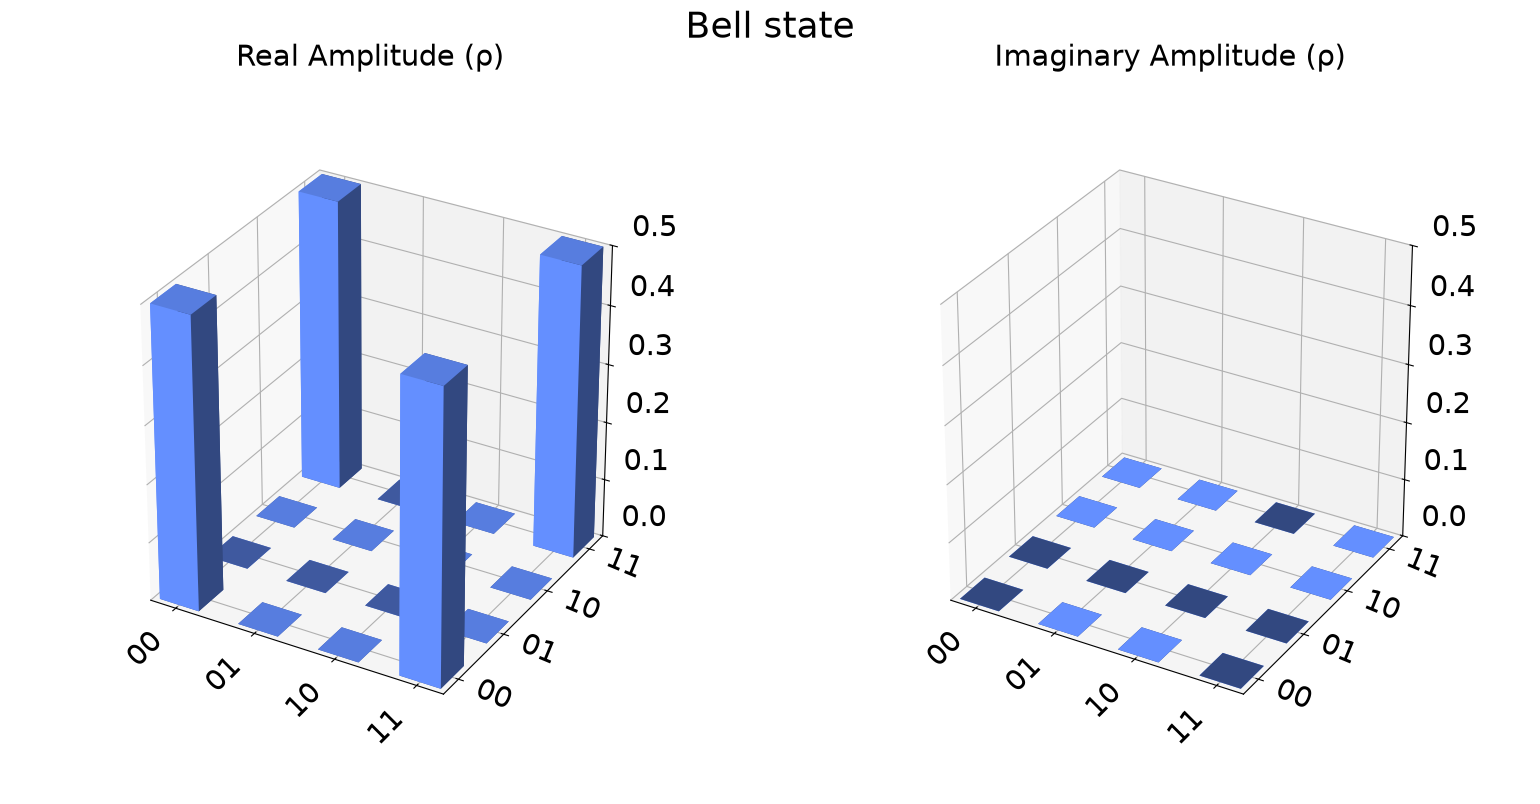

In [192]:
rho_bell = DensityMatrix(bell.ravel())
rho_q0 = partial_trace(rho_bell, [1])

show(rho_q0, r'\rho_{q_0} = \mathrm{Tr}_{q_1}\rho = ')
print(f'purity of the Bell state : {rho_bell.purity().real:.3f}')
print(f'purity of qubit 0        : {rho_q0.purity().real:.3f}')
plot_state_city(rho_bell, title='Bell state')

### 1.8 Hermitian matrices, eigenvalues and eigenvectors

Observables are Hermitian, $A = A^\dagger$: real eigenvalues, orthonormal eigenvectors and
$A = \sum_i \lambda_i |a_i\rangle\langle a_i|$. The eigenvectors of $X, Y, Z$ are the bases from 1.3.

In [193]:
Y = np.array([[0, -1j], [1j, 0]])
Z = np.array([[1, 0], [0, -1]])

A = Y                                  # try X, Z, X + Z, ...
print('Hermitian:', np.allclose(A, A.conj().T))

eigvals, eigvecs = np.linalg.eigh(A)
print('eigenvalues:', eigvals)
show(eigvecs, r'\text{eigenvectors (columns)} = ')

A_rebuilt = sum(l * np.outer(v, v.conj()) for l, v in zip(eigvals, eigvecs.T))
print('A == sum_i l_i |a_i><a_i| :', np.allclose(A_rebuilt, A))

Hermitian: True
eigenvalues: [-1.  1.]


<IPython.core.display.Latex object>

A == sum_i l_i |a_i><a_i| : True


### 1.9 Projective measurement, mean value

Measuring $A = \sum_i \lambda_i P_i$ on $|\psi\rangle$ gives $\lambda_i$ with probability $p_i = \langle\psi|P_i|\psi\rangle$
and leaves the state $P_i|\psi\rangle / \sqrt{p_i}$. For non-degenerate eigenvalues $P_i = |a_i\rangle\langle a_i|$. The mean value:

$$\langle A\rangle = \sum_i \lambda_i p_i = \langle\psi|A|\psi\rangle = \mathrm{Tr}(\rho A)$$

In [194]:
A = Z                                  # try X, Y
state = psi

eigvals, eigvecs = np.linalg.eigh(A)
probs = []
for l, v in zip(eigvals, eigvecs.T):
    P = np.outer(v, v.conj())
    p = braket(state, P @ state).real
    probs.append(p)
    print(f'outcome {l:+.0f}: p = {p:.3f}')
    if p > 1e-12:
        show(P @ state / np.sqrt(p), r'\text{state after: } ')

print(f'sum l_i p_i = {sum(l*p for l, p in zip(eigvals, probs)):.3f}')
print(f'<psi|A|psi> = {braket(state, A @ state).real:.3f}')
print(f'Tr(rho A)   = {np.trace(state @ state.conj().T @ A).real:.3f}')
print(f'Qiskit      = {Statevector(state.ravel()).expectation_value(Operator(A)).real:.3f}')

outcome -1: p = 0.667


<IPython.core.display.Latex object>

outcome +1: p = 0.333


<IPython.core.display.Latex object>

sum l_i p_i = -0.333
<psi|A|psi> = -0.333
Tr(rho A)   = -0.333
Qiskit      = -0.333


### 1.10 Global and relative phase

A global phase $e^{i\gamma}|\psi\rangle$ cannot be observed: same probabilities in every basis, same $\rho$.
A relative phase $\frac{1}{\sqrt2}(|0\rangle + e^{i\varphi}|1\rangle)$ can: it rotates the state around the Z axis
of the Bloch sphere and changes the X- and Y-basis probabilities.

global  : same vector? False | equiv? True | same rho? True
relative: equiv? False
Z-basis probabilities: [0.5 0.5] [0.5 0.5] [0.5 0.5]


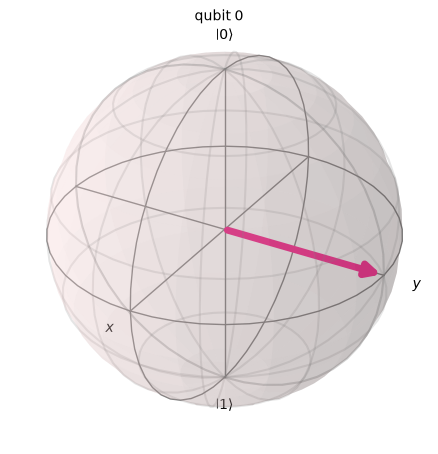

In [195]:
gamma, phi = 0.7, np.pi/2              # try other angles

a = Statevector(plus.ravel())
b = Statevector(np.exp(1j*gamma) * plus.ravel())
c = Statevector(np.array([1, np.exp(1j*phi)]) / np.sqrt(2))

print('global  : same vector?', np.allclose(a.data, b.data), '| equiv?', a.equiv(b),
      '| same rho?', np.allclose(DensityMatrix(a).data, DensityMatrix(b).data))
print('relative: equiv?', a.equiv(c))
print('Z-basis probabilities:', a.probabilities(), b.probabilities(), c.probabilities())
plot_bloch_multivector(c)

## 2. Gates are matrices

A gate is a unitary matrix, $U^\dagger U = I$.

$$
X = \begin{pmatrix}0&1\\1&0\end{pmatrix},\
Y = \begin{pmatrix}0&-i\\i&0\end{pmatrix},\
Z = \begin{pmatrix}1&0\\0&-1\end{pmatrix},\
H = \tfrac{1}{\sqrt2}\begin{pmatrix}1&1\\1&-1\end{pmatrix},\
S = \begin{pmatrix}1&0\\0&i\end{pmatrix},\
T = \begin{pmatrix}1&0\\0&e^{i\pi/4}\end{pmatrix}
$$

$$
R_x(\theta) = e^{-i\frac{\theta}{2}X} = \begin{pmatrix}\cos\frac{\theta}{2}&-i\sin\frac{\theta}{2}\\-i\sin\frac{\theta}{2}&\cos\frac{\theta}{2}\end{pmatrix},\quad
R_y(\theta) = e^{-i\frac{\theta}{2}Y} = \begin{pmatrix}\cos\frac{\theta}{2}&-\sin\frac{\theta}{2}\\\sin\frac{\theta}{2}&\cos\frac{\theta}{2}\end{pmatrix},\quad
R_z(\theta) = e^{-i\frac{\theta}{2}Z} = \begin{pmatrix}e^{-i\theta/2}&0\\0&e^{i\theta/2}\end{pmatrix}
$$

$R_z(\pi/2)$ and $R_z(\pi/4)$ equal $S$ and $T$ only up to a global phase.

$$
\text{CNOT} = \begin{pmatrix}1&0&0&0\\0&1&0&0\\0&0&0&1\\0&0&1&0\end{pmatrix},\quad
\text{CZ} = \begin{pmatrix}1&0&0&0\\0&1&0&0\\0&0&1&0\\0&0&0&-1\end{pmatrix},\quad
\text{SWAP} = \begin{pmatrix}1&0&0&0\\0&0&1&0\\0&1&0&0\\0&0&0&1\end{pmatrix}
$$

In [196]:
gates = [XGate(), YGate(), ZGate(), HGate(), SGate(), TGate(), RXGate(np.pi/2), RYGate(np.pi/2), RZGate(np.pi/4)]

for g in gates:
    U = Operator(g).data
    params = ', '.join(pi_check(p, output='latex') for p in g.params)
    show(U, rf'\text{{{g.name}}}' + (f'({params})' if params else '') + ' = ')
    print('unitary:', np.allclose(U.conj().T @ U, np.eye(len(U))), '| Hermitian:', np.allclose(U, U.conj().T))

<IPython.core.display.Latex object>

unitary: True | Hermitian: True


<IPython.core.display.Latex object>

unitary: True | Hermitian: True


<IPython.core.display.Latex object>

...

unitary: True | Hermitian: False


<IPython.core.display.Latex object>

unitary: True | Hermitian: False


<IPython.core.display.Latex object>

unitary: True | Hermitian: False


Applying a gate = matrix times vector.

In [197]:
H = Operator(HGate()).data

show(H @ ket0, r'H|0\rangle = ')
Statevector.from_label('0').evolve(HGate()).draw('latex')

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

### 2.1 Qubit ordering: Qiskit vs. textbook

**Motivation: a bit string is a binary number.** In a decimal number the rightmost digit is the least significant one,
$345 = 3\cdot 10^2 + 4\cdot 10^1 + 5\cdot 10^0$. The same holds in binary: $110_2 = 1\cdot 2^2 + 1\cdot 2^1 + 0\cdot 2^0 = 6$.

Qiskit gives qubit $q_k$ the weight $2^k$. The label $|q_{n-1}\dots q_1 q_0\rangle$ read as a binary number is then directly
the index of its amplitude in the state vector, and $q_0$ is the rightmost (least significant) bit:

$$|q_{n-1}\dots q_1 q_0\rangle \;\longrightarrow\; \text{index} = \sum_k q_k\, 2^k$$

In [199]:
state = Statevector.from_label('110')
print('index of the amplitude 1:', np.argmax(abs(state.data)))
Statevector.from_int(6, 2**3).draw('latex')

index of the amplitude 1: 6


<IPython.core.display.Latex object>

**Two conventions.** Both read the label as a binary number, they differ in which qubit is the most significant digit.

| | label | vector | qubit 0 is |
|---|---|---|---|
| textbook | $\vert q_0 q_1\rangle$ | $\vert q_0\rangle\otimes\vert q_1\rangle$ | the leftmost bit |
| Qiskit | $\vert q_1 q_0\rangle$ | $\vert q_1\rangle\otimes\vert q_0\rangle$ | the rightmost bit |

The same physical state $q_0 = 1,\ q_1 = 0$ is therefore a different vector:

$$\text{textbook: } |q_0 q_1\rangle = |10\rangle = (0, 0, 1, 0)^T, \qquad \text{Qiskit: } |q_1 q_0\rangle = |01\rangle = (0, 1, 0, 0)^T$$

Likewise $X$ on $q_0$ is $X\otimes I$ in the textbook but $I\otimes X$ in Qiskit.

In [200]:
q0, q1 = ket1, ket0

show(np.kron(q0, q1), r'\text{textbook: } |q_0\rangle\otimes|q_1\rangle = ')
show(np.kron(q1, q0), r'\text{Qiskit: } |q_1\rangle\otimes|q_0\rangle = ')

qc = QuantumCircuit(2)
qc.x(0)
Statevector(qc).draw('latex')

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

**CNOT with control $q_0$ and target $q_1$.** The rule is the same in both conventions (if $q_0 = 1$, flip $q_1$),
only the order of the basis states differs.

Textbook, basis $|q_0 q_1\rangle$: the control is the left bit, $|10\rangle \leftrightarrow |11\rangle$ (indices 2 and 3) are swapped:

$$\text{CNOT} = \begin{pmatrix}1&0&0&0\\0&1&0&0\\0&0&0&1\\0&0&1&0\end{pmatrix}$$

Qiskit, basis $|q_1 q_0\rangle$: the control is the right bit, $|01\rangle \leftrightarrow |11\rangle$ (indices 1 and 3) are swapped:

$$\texttt{cx(0, 1)} = \begin{pmatrix}1&0&0&0\\0&0&0&1\\0&0&1&0\\0&1&0&0\end{pmatrix}$$

Both matrices describe the same gate. Switching the convention only reorders the basis, i.e. swaps the tensor factors:
$U_\text{Qiskit} = \text{SWAP}\; U_\text{textbook}\; \text{SWAP}$.

`reverse_bits()` renames the qubits $q_k \to q_{n-1-k}$: `cx(0, 1)` becomes `cx(1, 0)`, whose Qiskit matrix is the textbook CNOT.

In [201]:
qc = QuantumCircuit(2)
qc.cx(0, 1)

for label in ['00', '01', '10', '11']:
    out = Statevector.from_label(label).evolve(qc)
    print(f'|{label}> -> |{list(out.probabilities_dict())[0]}>')

|00> -> |00>
|01> -> |11>
|10> -> |10>
|11> -> |01>


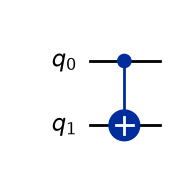

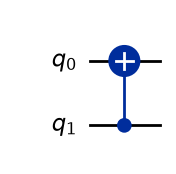

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

U_qiskit == SWAP U_textbook SWAP : True


In [202]:
U_qiskit = Operator(qc).data
U_textbook = Operator(qc.reverse_bits()).data
SWAP = Operator(SwapGate()).data

display(qc.draw('mpl'), qc.reverse_bits().draw('mpl'))
show(U_qiskit, r'\text{Qiskit cx(0, 1)} = ')
show(U_textbook, r'\text{textbook CNOT} = ')
print('U_qiskit == SWAP U_textbook SWAP :', np.allclose(U_qiskit, SWAP @ U_textbook @ SWAP))

**In practice**

- Matrices by hand: order the factors as $q_{n-1}\otimes\dots\otimes q_1\otimes q_0$ (in 2.2, $X$ on $q_1$ and $H$ on $q_0$ is `np.kron(X, H)`).
- `Pauli('XI')` is $X$ on $q_1$, `Statevector.from_label('01')` has $q_0 = 1$.
- Measured counts use the same order: the key `'01'` means $c_1 = 0,\ c_0 = 1$.
- To compare with a matrix from the lecture, use `reverse_bits()`.

### 2.2 Matrix of a whole circuit

Gates applied one after another multiply from the right to the left ($U_2 U_1$),
gates on different qubits at the same time combine by the tensor product.

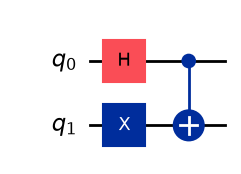

<IPython.core.display.Latex object>

U == CX (X⊗H) : True


In [203]:
qc = QuantumCircuit(2)
qc.h(0)
qc.x(1)
qc.cx(0, 1)
display(qc.draw('mpl'))

H, X, CX = (Operator(g).data for g in (HGate(), XGate(), CXGate()))
U_by_hand = CX @ np.kron(X, H)

show(Operator(qc), r'U = ')
print('U == CX (X⊗H) :', np.allclose(Operator(qc).data, U_by_hand))

### 2.3 Gate identities, global phase again

`==` compares matrices (up to rounding), `equiv` ignores a global phase. Try $HXH = Z$, $SS = Z$, $TT = S$, $XZ$ vs. $ZX$, ...

The circuit order is the reverse of the product order: `x` followed by `z` is the matrix $ZX$.

In [204]:
lhs = QuantumCircuit(1)
lhs.x(0)
lhs.z(0)

rhs = QuantumCircuit(1)
rhs.z(0)
rhs.x(0)

show(Operator(lhs), r'\text{lhs} = ')
show(Operator(rhs), r'\text{rhs} = ')
print('equal :', Operator(lhs) == Operator(rhs))
print('equiv :', Operator(lhs).equiv(Operator(rhs)))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

equal : False
equiv : True


## 3. Building a circuit gate by gate

### 3.1 Structure of a circuit

Qubits (quantum register) and classical bits (classical register) are the horizontal wires,
time goes from left to right, all qubits start in $|0\rangle$.

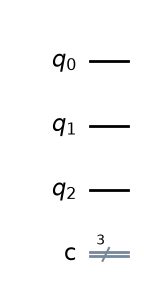

In [205]:
qr = QuantumRegister(3, 'q')
cr = ClassicalRegister(3, 'c')
qc = QuantumCircuit(qr, cr)

qc.draw('mpl')

### 3.2 Adding gates

`inspect` draws the circuit, prints the statevector and shows it on the Bloch spheres.

In [206]:
def inspect(qc):
    state = Statevector(qc)
    display(qc.draw('mpl'), state.draw('latex'), plot_bloch_multivector(state))

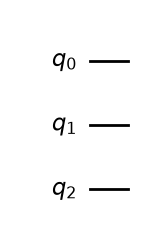

<IPython.core.display.Latex object>

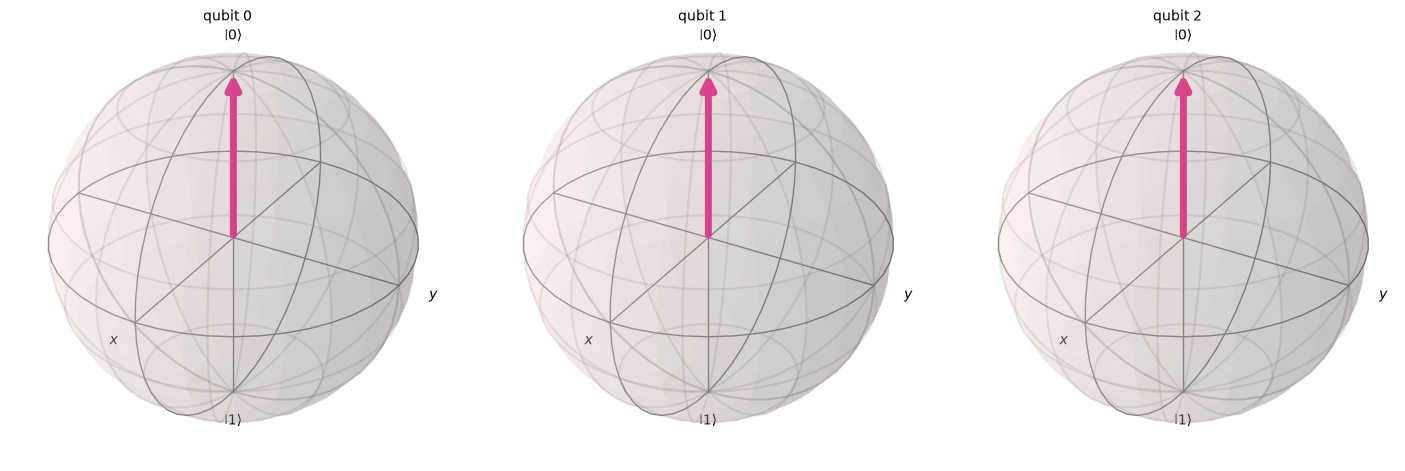

In [207]:
qc = QuantumCircuit(3)
inspect(qc)

Each of the following cells *adds* a gate to the same `qc`: re-running a cell adds it once more.
To start again, re-run the cell above.

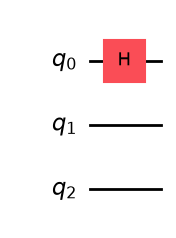

<IPython.core.display.Latex object>

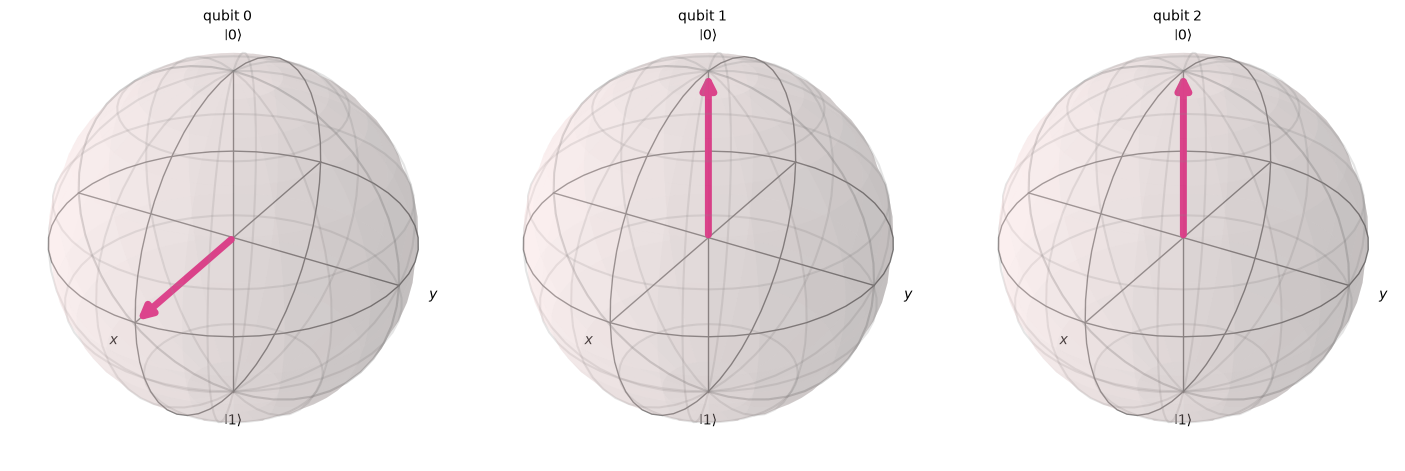

In [208]:
qc.h(0)
inspect(qc)

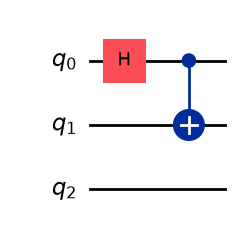

<IPython.core.display.Latex object>

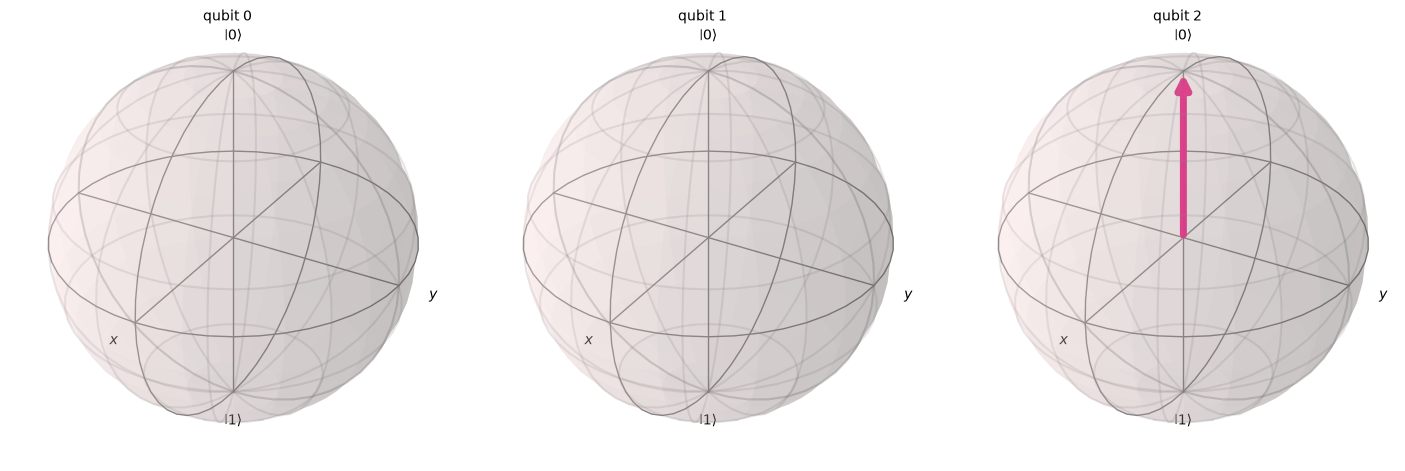

In [209]:
qc.cx(0, 1)
inspect(qc)

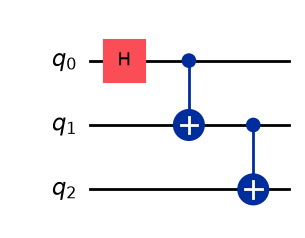

<IPython.core.display.Latex object>

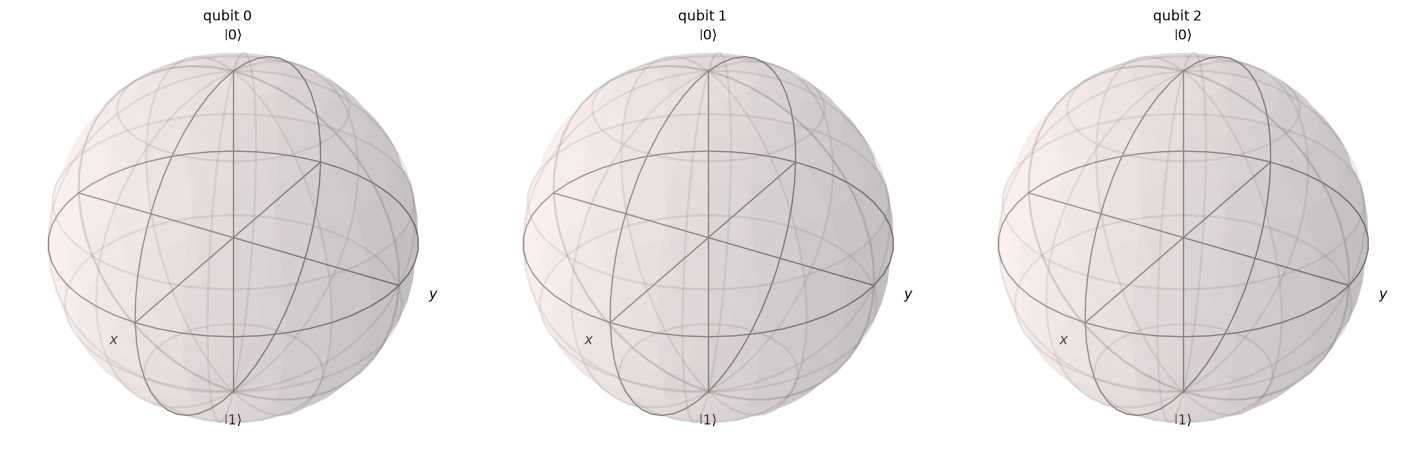

In [210]:
qc.cx(1, 2)
inspect(qc)

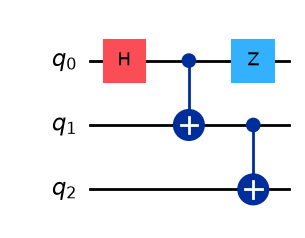

<IPython.core.display.Latex object>

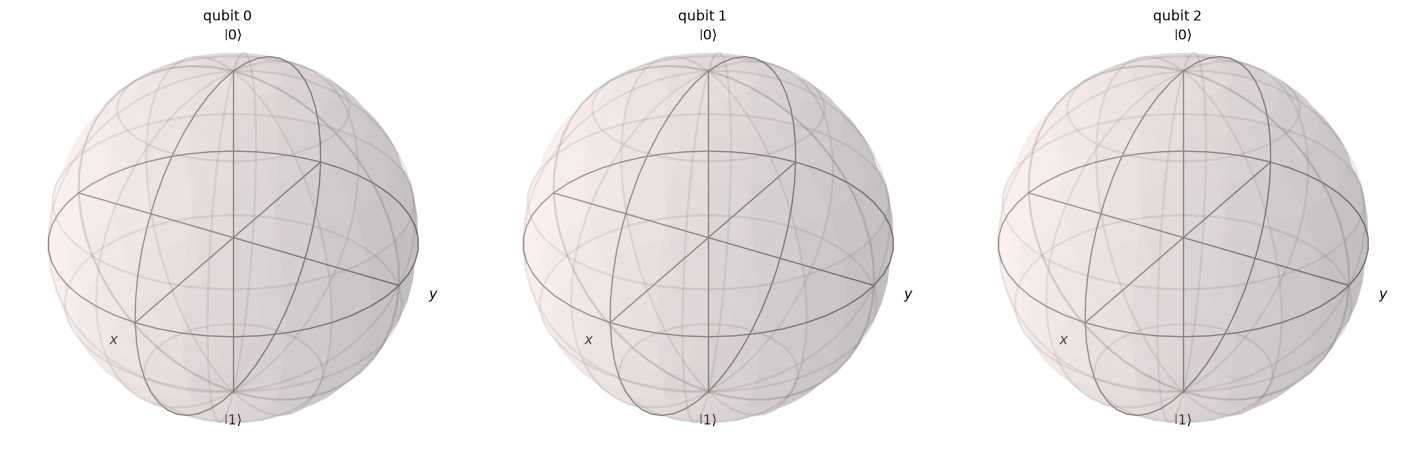

In [211]:
qc.z(0)
inspect(qc)

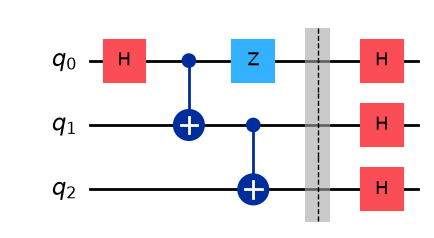

<IPython.core.display.Latex object>

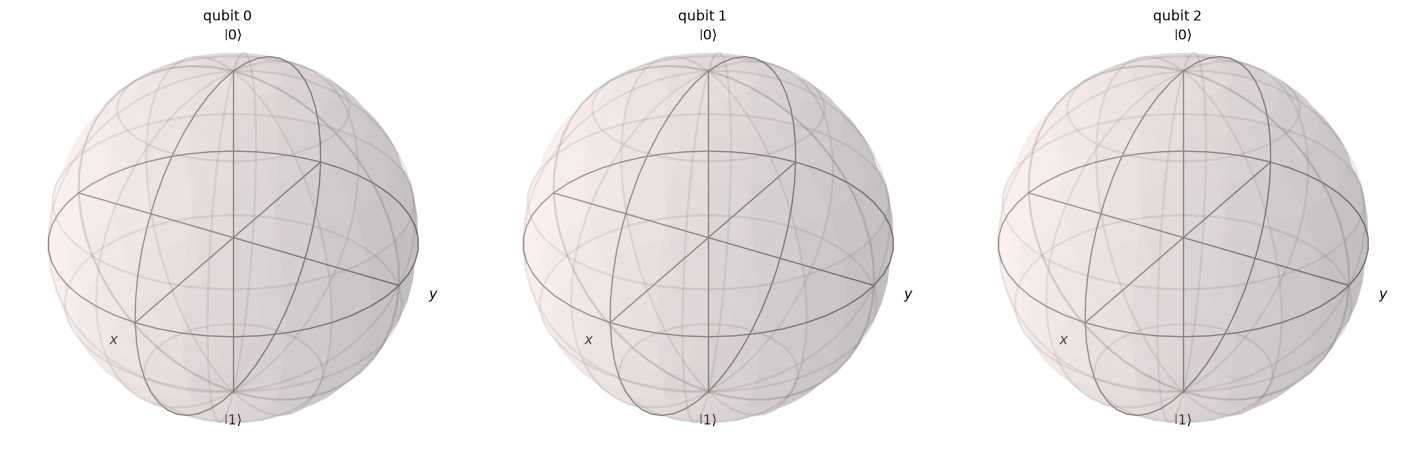

In [212]:
qc.barrier()
qc.h([0, 1, 2])
inspect(qc)

qubits: 3 | depth: 4 | gates: {'h': 4, 'cx': 2, 'z': 1, 'barrier': 1}


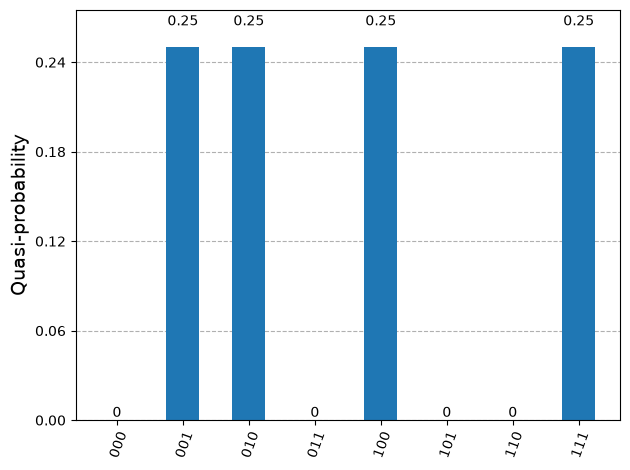

In [213]:
print('qubits:', qc.num_qubits, '| depth:', qc.depth(), '| gates:', dict(qc.count_ops()))
plot_histogram(Statevector(qc).probabilities_dict())

### 3.3 Statevector after every gate

In [214]:
def step_through(qc):
    sub = qc.copy_empty_like()
    display(Statevector(sub).draw('latex', prefix=r'\text{start: }'))
    for instr in qc.data:
        if instr.operation.name in ('barrier', 'measure'):
            continue
        sub.append(instr)
        qubits = [qc.find_bit(q).index for q in instr.qubits]
        display(Statevector(sub).draw('latex', prefix=rf'\text{{{instr.operation.name} {qubits}: }}'))

step_through(qc)

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

### 3.4 Playground

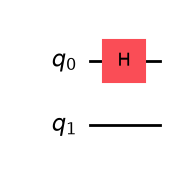

<IPython.core.display.Latex object>

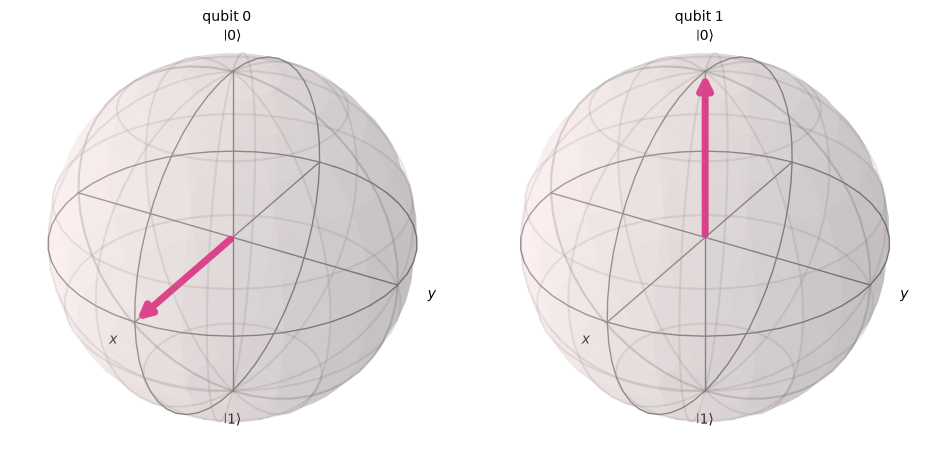

<IPython.core.display.Latex object>

In [215]:
qc = QuantumCircuit(2)
qc.h(0)
# qc.x(1)
# qc.cx(0, 1)
# qc.s(0)
# qc.t(0)
# qc.ry(np.pi/3, 1)
# qc.rz(np.pi/2, 0)
# qc.swap(0, 1)

inspect(qc)
show(Operator(qc), r'U = ')

## 4. Measurement

### 4.1 Adding measurements

`measure(q, c)` is a projective measurement of qubit `q` in the Z basis, the result is stored in the classical bit `c`.
A `Statevector` cannot represent a random outcome, so we sample the circuit on a simulator.

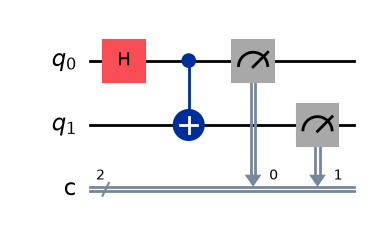

In [216]:
qc = QuantumCircuit(2, 2)
qc.h(0)
qc.cx(0, 1)
qc.measure([0, 1], [0, 1])
qc.draw('mpl')

{'11': 495, '00': 505}


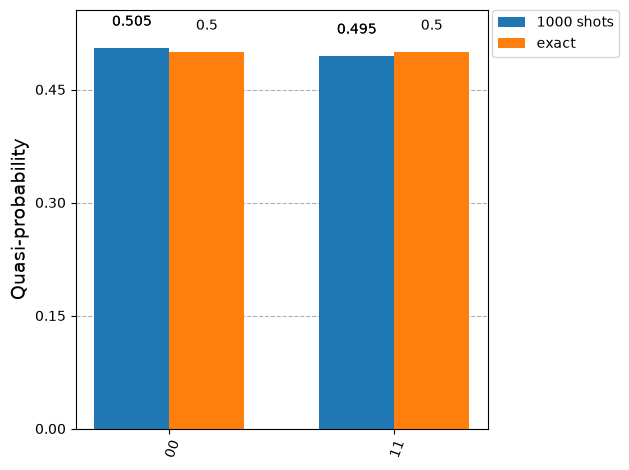

In [217]:
sim = AerSimulator()
shots = 1000                           # try 10, 100, 10000

counts = sim.run(transpile(qc, sim), shots=shots).result().get_counts()
exact = Statevector(qc.remove_final_measurements(inplace=False)).probabilities_dict()

print(counts)
plot_histogram([counts, exact], legend=[f'{shots} shots', 'exact'])

### 4.2 Measuring in another basis, mean value

The hardware measures only in the Z basis. To measure in the X basis apply $H$ first, for the Y basis $S^\dagger$ and then $H$.
From the counts: $\langle A\rangle \approx (N_0 - N_1)/N$ (eigenvalues $+1$ and $-1$).

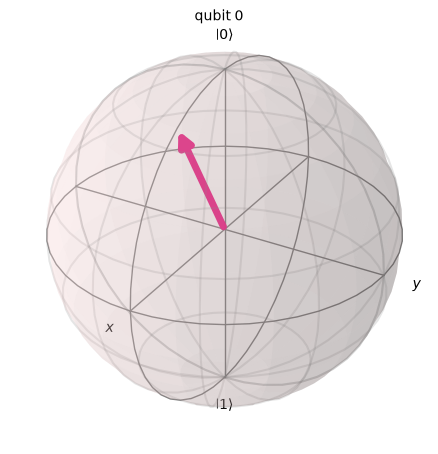

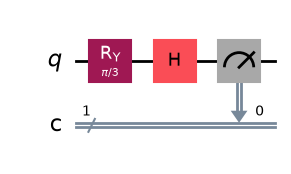

{'1': 137, '0': 1863}
<X> from counts = 0.863,  exact = 0.866


In [230]:
theta = np.pi/3
basis = 'X'                            # 'Z', 'X' or 'Y'

qc = QuantumCircuit(1, 1)
qc.ry(theta, 0)
prepared = Statevector(qc)

if basis == 'X':
    qc.h(0)
elif basis == 'Y':
    qc.sdg(0)
    qc.h(0)

state = Statevector(qc)
display(plot_bloch_multivector(state))
qc.measure(0, 0)
display(qc.draw('mpl'))

shots = 2000
counts = sim.run(transpile(qc, sim), shots=shots).result().get_counts()
mean = (counts.get('0', 0) - counts.get('1', 0)) / shots

print(counts)
print(f'<{basis}> from counts = {mean:.3f},  exact = {prepared.expectation_value(Pauli(basis)).real:.3f}')

### 4.3 What the measurement does to the state

Measure only $q_0$ of a Bell state and look at the statevector before and after (a single shot).
The second qubit collapses too.

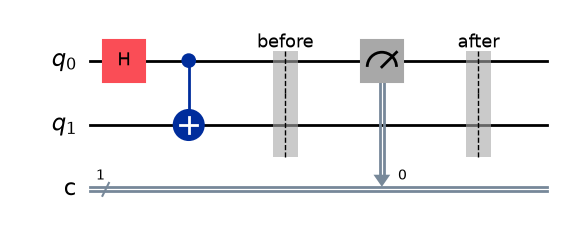

outcome: {'1': 1}


<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [219]:
qc = QuantumCircuit(2, 1)
qc.h(0)
qc.cx(0, 1)
qc.save_statevector('before')
qc.measure(0, 0)
qc.save_statevector('after')
display(qc.draw('mpl'))

result = sim.run(qc, shots=1).result()
print('outcome:', result.get_counts())
display(result.data()['before'].draw('latex', prefix=r'\text{before: }'),
        result.data()['after'].draw('latex', prefix=r'\text{after: }'))

### 4.4 Measurement without reading the result

If the outcome is not known, the state after the measurement is the mixture $\rho' = \sum_i P_i \rho P_i$:
the off-diagonal elements (coherences) vanish and the purity drops.
Compare with $\rho_{q_0}$ of the Bell state in 1.7.

In [220]:
rho = DensityMatrix.from_label('+')    # try '0', '-', 'r', ...
rho_after = sum(P @ rho.data @ P for P in (P0, P1))

show(rho, r'\rho = ')
show(rho_after, r"\rho' = ")
print(f'purity before: {rho.purity().real:.3f} | after: {DensityMatrix(rho_after).purity().real:.3f}')

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

purity before: 1.000 | after: 0.500


### 4.5 Measuring all qubits

`measure_all()` adds a barrier, a new classical register and measures every qubit.

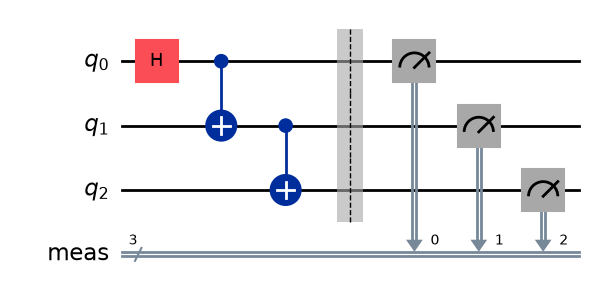

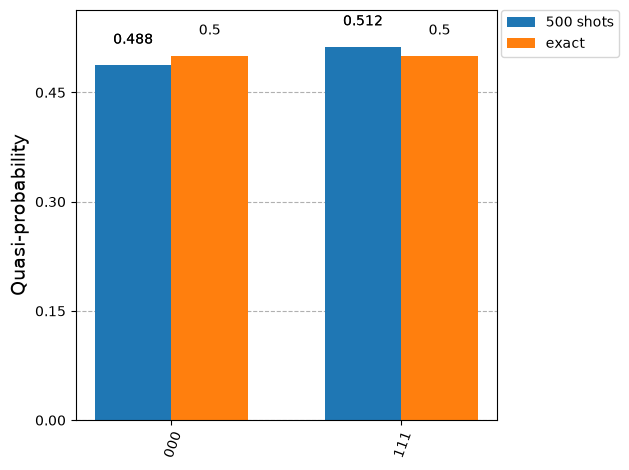

In [221]:
qc = QuantumCircuit(3)
qc.h(0)
qc.cx(0, 1)
qc.cx(1, 2)
exact = Statevector(qc).probabilities_dict()

qc.measure_all()
display(qc.draw('mpl'))

counts = sim.run(transpile(qc, sim), shots=500).result().get_counts()
plot_histogram([counts, exact], legend=['500 shots', 'exact'])

## 5. Quantum teleportation

Transfer of an unknown state $|\psi\rangle = \alpha|0\rangle + \beta|1\rangle$ from $q_0$ to Bob's qubit $q_2$ using a shared entangled pair.
The state is never measured and never sent, only two classical bits travel from Alice to Bob.

1. prepare $|\psi\rangle$ on $q_0$,
2. Alice ($q_1$) and Bob ($q_2$) share the Bell pair $\frac{1}{\sqrt2}(|00\rangle + |11\rangle)$,
3. Alice applies CNOT ($q_0 \to q_1$) and $H$ on $q_0$, then measures $q_0, q_1$ and gets the bits $m_0, m_1$,
4. Bob applies $X^{m_1}$ and then $Z^{m_0}$ to his qubit and obtains $|\psi\rangle$.

In [ ]:
q_state = QuantumRegister(1, 'q0 (state)')
q_alice = QuantumRegister(1, 'q1 (Alice)')
q_bob = QuantumRegister(1, 'q2 (Bob)')
cr = ClassicalRegister(2, 'c')

qc = QuantumCircuit(q_state, q_alice, q_bob, cr)
qc.u(np.pi/3, -np.pi/4, 0, 0)          # the state to teleport, try other angles
psi_in = partial_trace(Statevector(qc), [1, 2])

display(qc.draw('mpl'))
plot_bloch_multivector(Statevector(qc))

### 5.1 Shared Bell pair

Alice's and Bob's qubits are entangled, so their Bloch vectors shrink to zero (see 1.7).

In [ ]:
qc.barrier()
qc.h(1)
qc.cx(1, 2)
qc.barrier()

display(qc.draw('mpl'))
plot_bloch_multivector(Statevector(qc))

### 5.2 Alice's operations

After CNOT and $H$ the state can be rewritten (Qiskit order $q_2 q_1 q_0$) as

$$\frac{1}{2}\sum_{m_0, m_1 \in \{0, 1\}} \underbrace{X^{m_1} Z^{m_0}|\psi\rangle}_{q_2} \otimes |m_1\rangle_{q_1} \otimes |m_0\rangle_{q_0}$$

Each outcome $m_1 m_0$ has probability $1/4$ and leaves Bob with $X^{m_1}Z^{m_0}|\psi\rangle$, which he can undo once he knows $m_0, m_1$.

In [ ]:
qc.cx(0, 1)
qc.h(0)
display(qc.draw('mpl'), Statevector(qc).draw('latex'))

qc.save_statevector('before_measure')

### 5.3 Measurement and Bob's corrections

A classically controlled gate is written with `if_test`: the block runs only if the classical bit has the given value.
`save_statevector` stores the state at that point of the simulation.

In [ ]:
qc.measure(0, 0)
qc.measure(1, 1)
qc.save_statevector('after_measure')

with qc.if_test((cr[1], 1)):
    qc.x(2)
with qc.if_test((cr[0], 1)):
    qc.z(2)
qc.save_statevector('after_corrections')

qc.draw('mpl')

### 5.4 Run it

One shot = one teleportation. Re-run the cell to get other outcomes $m_1 m_0$.
Bob's qubit after the corrections has the same Bloch vector as the input state. Try removing the corrections.

In [ ]:
result = sim.run(qc, shots=1).result()
data = result.data()
print('measured m1 m0:', result.get_counts())

for label in ('before_measure', 'after_measure', 'after_corrections'):
    display(plot_bloch_multivector(data[label], title=label))

rho_bob = partial_trace(data['after_corrections'], [0, 1])
print(f'fidelity of Bob\'s qubit with the input state: {state_fidelity(rho_bob, psi_in):.3f}')